# **Sequential Graph**

In [1]:
from typing import TypedDict;

class State(TypedDict):
    current: str;
    cleaned: str;
    title_case: str;
    final: str;

def clean_node(state: State) -> dict:

    """Step 1 — Strip whitespace and lowercase"""

    cleaned = state["current"].strip().lower();

    print(f"[clean] `                      {state["current"]}` → `{cleaned}`");

    return {"cleaned": cleaned, "current": cleaned}; # Current State Update

def titlecase_node(state: State) -> dict:

    """Step 2 — Uppercase first letter of each word"""

    title = state["current"].title();

    print(f"[uppercase] `{state["current"]}` → `{title}`");

    return {"title_case": title, "current": title};

def format_node(state: State) -> dict:

    """Step 3 — Wrap in a formatted output string"""

    final = f"✅ Result: [{state["current"]}]";

    print(f"[format]    `{state["current"]}` → `{final}`");

    return {"final": final, "current": final};

In [2]:
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(State);

builder.add_node("clean", clean_node);

builder.add_node("titlecase", titlecase_node);

builder.add_node("format", format_node);

builder.add_edge(START, "clean");

builder.add_edge("clean", "format");

builder.add_edge("format", "titlecase");

builder.add_edge("titlecase", END);

graph = builder.compile();

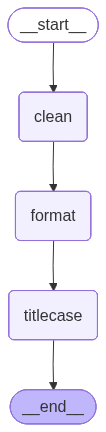

In [3]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [4]:
inputs = [
    "Learning Langgraph!",
    "Building Ai Agents"
];

for raw in inputs:

    r = graph.invoke(
        {
            "current": raw,
            "cleaned": "",
            "title_case": "",
            "final": ""
        }
    );
    
    print(f"Output: {r["final"]}\n");

[clean] `                      Learning Langgraph!` → `learning langgraph!`
[format]    `learning langgraph!` → `✅ Result: [learning langgraph!]`
[uppercase] `✅ Result: [learning langgraph!]` → `✅ Result: [Learning Langgraph!]`
Output: ✅ Result: [learning langgraph!]

[clean] `                      Building Ai Agents` → `building ai agents`
[format]    `building ai agents` → `✅ Result: [building ai agents]`
[uppercase] `✅ Result: [building ai agents]` → `✅ Result: [Building Ai Agents]`
Output: ✅ Result: [building ai agents]

